# Progetto: DP pseudo-polinomiale vs PLI per P_m||C_max

Confronto tra due modi di risolvere lo scheduling su m macchine identiche (minimizzare il makespan):

1. una **programmazione dinamica pseudo-polinomiale** (fatta a mano, con numpy)
2. una **formulazione PLI** risolta con AMPL + HiGHS

Genero delle istanze di prova (piccole, medie, grandi, e "tante" - large_n), le risolvo con entrambi i
metodi dandogli al massimo 5 minuti a testa, e confronto tempo, memoria e quante ne risolvono.

In [1]:
import random
import time
import signal
import resource
import tracemalloc
import subprocess
import tempfile
import json
import sys
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import psutil
from amplpy import AMPL

/home/gabriele/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## Parametri

`M` e' il numero di macchine, tenuto fisso per tutto il notebook (per fare uno sweep su un altro
valore di m basta cambiare qui e rieseguire tutto). Le altre dimensioni (n, p_j) cambiano per categoria.

Oltre alle 4 categorie "di taglia" (small/medium/large/large_n), aggiungo 3 categorie che tengono
n fisso (come "medium") e fanno variare solo **come sono distribuiti i p_j**, per vedere se la
forma della distribuzione (non solo la dimensione) cambia le prestazioni di DP e PLI:

- `narrow`: uniforme molto stretta (job quasi tutti della stessa durata)
- `wide`: uniforme molto larga (job molto eterogenei)
- `exponential`: esponenziale (tanti job piccoli, pochi job grandi - coda lunga)

In [2]:
M = 2               # numero di macchine per questo run
TIMEOUT_SEC = 300   # 5 minuti, oltre i quali si passa all'istanza successiva
N_ISTANZE = 10       # istanze per categoria

# per ogni categoria: range del numero di job (n) e come sono generati i p_j.
# dist="uniforme" -> p_j ~ uniforme intero in (min,max)
# dist="esponenziale" -> p_j ~ esponenziale di media "media", arrotondato (minimo 1)
CATEGORIE = {
    "small":       {"n": (8, 15),     "dist": "uniforme",     "p": (1, 100)},
    "medium":      {"n": (18, 28),    "dist": "uniforme",     "p": (1, 200)},
    "large":       {"n": (30, 50),    "dist": "uniforme",     "p": (1, 300)},
    "large_n":     {"n": (200, 1000), "dist": "uniforme",     "p": (1, 50)},
    "narrow":      {"n": (18, 28),    "dist": "uniforme",     "p": (45, 55)},    # equidistribuita stretta
    "wide":        {"n": (18, 28),    "dist": "uniforme",     "p": (1, 1000)},  # equidistribuita larga
    "exponential": {"n": (18, 28),    "dist": "esponenziale", "media": 50},
}

# ordine "logico" delle categorie nei grafici/tabelle: prima quelle di taglia,
# poi quelle di distribuzione. Per difetto pandas ordina alfabeticamente
# (exponential, large, large_n, medium, narrow, small, wide) mischiando le due
# famiglie di categorie - qui invece fissiamo l'ordine che vogliamo noi.
CATEGORIA_ORDINE = list(CATEGORIE.keys())

# colori usati in tutti i grafici, piu' vivaci dei default di matplotlib
COLORI = {"DP": "#2ecc71", "PLI": "#e67e22"}  # verde per DP, arancione per PLI

## Generazione delle istanze

Niente file su disco, le tengo semplicemente in una lista di dizionari. Uso l'indice `idx` come
seed cosi' le istanze sono sempre le stesse se rieseguo il notebook.

In [3]:
def genera_istanza(categoria, idx):
    cfg = CATEGORIE[categoria]
    rng = random.Random(idx)
    n = rng.randint(*cfg["n"])

    if cfg["dist"] == "uniforme":
        p = [rng.randint(*cfg["p"]) for _ in range(n)]
    elif cfg["dist"] == "esponenziale":
        p = [max(1, round(rng.expovariate(1 / cfg["media"]))) for _ in range(n)]

    return {"id": f"{categoria}_{idx:02d}", "categoria": categoria, "n": n, "m": M, "p": p}


istanze = []
for cat in CATEGORIE:
    for i in range(N_ISTANZE):
        istanze.append(genera_istanza(cat, i))

print(f"Generate {len(istanze)} istanze (m={M})")
for ist in istanze[::10]:
    print(ist["id"], "n=", ist["n"], "P=", sum(ist["p"]))

Generate 70 istanze (m=2)
small_00 n= 14 P= 706
medium_00 n= 24 P= 2469
large_00 n= 42 P= 6815
large_n_00 n= 594 P= 14775
narrow_00 n= 24 P= 1194
wide_00 n= 24 P= 13366
exponential_00 n= 24 P= 1460


## Algoritmo DP

Stato = vettore di carico delle prime m-1 macchine, rappresentato come array booleano numpy
(la macchina m e' implicita: il suo carico e' `P - somma delle altre`). Per ogni job provo ad
assegnarlo a una delle prime m-1 macchine (shift dell'array lungo quella dimensione) oppure
all'ultima (l'array resta uguale, e' gia' incluso perche' parto da una copia).

Se lo stato sarebbe troppo grande (P^(m-1) sopra una soglia) non ci provo nemmeno, per non
rischiare di riempire tutta la RAM del computer.

In [4]:
SOGLIA_MEMORIA = 1_500_000_000


def solve_dp(n, m, p):
    P = sum(p)
    k = m - 1  # dimensioni esplicite dell'array

    if k == 0:
        return P, "OK"  # una macchina sola, ci va tutto sopra

    if (P + 1) ** k > SOGLIA_MEMORIA:
        return None, "MEMORY_GUARD"

    shape = (P + 1,) * k
    R = np.zeros(shape, dtype=bool)
    R[(0,) * k] = True

    for pi in p:
        if pi == 0:
            continue
        R_prima = R
        R_dopo = R_prima.copy()  # ramo "job sull'ultima macchina": stato invariato, gia' qui
        for h in range(k):
            dst = [slice(None)] * k
            src = [slice(None)] * k
            dst[h] = slice(pi, P + 1)
            src[h] = slice(0, P + 1 - pi)
            R_dopo[tuple(dst)] |= R_prima[tuple(src)]
        R = R_dopo

    coords = np.array(np.nonzero(R)).T
    carico_ultima_macchina = P - coords.sum(axis=1)
    makespan = np.maximum(coords.max(axis=1), carico_ultima_macchina)
    return int(makespan.min()), "OK"

In [5]:
# controllo veloce a mano: 3 job da 3 su 2 macchine -> il meglio e' {3,3} e {3}, makespan 6
assert solve_dp(3, 2, [3, 3, 3])[0] == 6
assert solve_dp(3, 1, [3, 3, 3])[0] == 9  # una sola macchina -> tutto sommato
print("DP: test ok")

DP: test ok


## Modello PLI

Il modello AMPL vero e proprio e' in `solvers/model_pmcmax.mod` (assignment + rottura di
simmetria sui carichi delle macchine, altrimenti il solver perde tempo su soluzioni equivalenti
che differiscono solo per come sono etichettate le macchine). Qui lo carico e lo risolvo con HiGHS.

In [6]:
def solve_pli(n, m, p):
    ampl = AMPL()
    ampl.read("solvers/model_pmcmax.mod")
    ampl.set["J"] = list(range(1, n + 1))
    ampl.set["M"] = list(range(1, m + 1))
    ampl.param["p"] = {j + 1: p[j] for j in range(n)}
    ampl.option["solver"] = "highs"

    try:
        ampl.solve()
    except Exception as e:
        ampl.close()
        if "demo license" in str(e).lower():
            return None, "LICENSE_LIMIT"
        return None, "ERRORE"

    if ampl.get_value("solve_result") != "solved":
        ampl.close()
        return None, "ERRORE"

    cmax = round(ampl.get_value("Cmax"))
    ampl.close()
    return cmax, "OK"

In [7]:
assert solve_pli(3, 2, [3, 3, 3])[0] == 6
assert solve_pli(3, 1, [3, 3, 3])[0] == 9
print("PLI: test ok")

HiGHS 1.14.0: optimal solution; objective 6
0 simplex iterations
0 branching nodes
HiGHS 1.14.0: optimal solution; objective 9
0 simplex iterations
0 barrier iterations
PLI: test ok


## Timeout e misura di tempo/memoria

Per la DP uso `signal.alarm` per il timeout e `tracemalloc` per la memoria, entrambi attorno
alla singola chiamata a `solve_dp` - funziona bene perche' e' codice Python/numpy puro, tutto
nello stesso processo.

Per il PLI ho scoperto (con un test rapido, controllando l'albero dei processi mentre girava)
che AMPL/HiGHS **non lanciano un eseguibile esterno separato**: girano dentro lo stesso processo
Python tramite binding C. Questo significa che ne' `tracemalloc` ne' un eventuale polling dei
"processi figli" vedono la vera memoria del solver (il motore C++ di HiGHS gestisce la sua
memoria fuori dalla vista di `tracemalloc`, che traccia bene solo le allocazioni tramite
l'allocatore Python/numpy).

L'unico modo per avere un numero affidabile e' isolare ogni chiamata al PLI in un **vero
processo del sistema operativo separato**: uso `subprocess.Popen` per lanciare
`harness/runner_pli.py` (lo stesso runner del progetto "ufficiale" a moduli separati, riusato
cosi' com'e') su un'istanza scritta su file JSON temporaneo, e faccio polling della RSS di
quel processo con `psutil` ogni 20ms. Il timeout ora e' applicato uccidendo il processo se
supera i secondi consentiti, invece che con `signal.alarm`.

In [8]:
class TempoScaduto(Exception):
    pass


def gestore_allarme(signum, frame):
    raise TempoScaduto()


def risolvi_con_limite(funzione, n, m, p, usa_tracemalloc=False, timeout=TIMEOUT_SEC):
    """Per la DP: gira in-process, timeout con signal.alarm, memoria con tracemalloc."""
    if usa_tracemalloc:
        tracemalloc.start()

    signal.signal(signal.SIGALRM, gestore_allarme)
    signal.alarm(timeout)
    inizio = time.time()
    try:
        cmax, stato = funzione(n, m, p)
    except TempoScaduto:
        cmax, stato = None, "TIMEOUT"
    finally:
        signal.alarm(0)  # disattivo l'allarme, l'istanza e' finita in tempo
    tempo = time.time() - inizio

    if usa_tracemalloc:
        _, picco = tracemalloc.get_traced_memory()
        tracemalloc.stop()
        mem_mb = picco / (1024 * 1024)
    else:
        mem_mb = 0.0

    return cmax, stato, tempo, mem_mb


def risolvi_pli_isolato(n, m, p, timeout=TIMEOUT_SEC):
    """Per il PLI: lancia harness/runner_pli.py come processo separato, cosi' possiamo
    misurare la sua RSS reale con psutil (AMPL/HiGHS girano dentro quel processo,
    tracemalloc non li vedrebbe se restassimo nello stesso processo del notebook)."""
    with tempfile.NamedTemporaryFile(mode="w", suffix=".json", delete=False) as f:
        json.dump({"n": n, "m": m, "p": p}, f)
        percorso_istanza = f.name

    inizio = time.time()
    proc = subprocess.Popen(
        [sys.executable, "harness/runner_pli.py", percorso_istanza],
        stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True,
    )

    picco_rss = 0
    stato_finale = None
    while True:
        try:
            ps_proc = psutil.Process(proc.pid)
            mem = ps_proc.memory_info().rss
            for figlio in ps_proc.children(recursive=True):
                mem += figlio.memory_info().rss
            picco_rss = max(picco_rss, mem)
        except psutil.NoSuchProcess:
            pass

        if proc.poll() is not None:
            break
        if time.time() - inizio > timeout:
            proc.kill()
            stato_finale = "TIMEOUT"
            break
        time.sleep(0.02)

    tempo = time.time() - inizio
    stdout, stderr = proc.communicate(timeout=10)
    os.unlink(percorso_istanza)
    mem_mb = picco_rss / (1024 * 1024)

    if stato_finale == "TIMEOUT":
        return None, "TIMEOUT", tempo, mem_mb
    if proc.returncode != 0:
        return None, "ERRORE", tempo, mem_mb
    try:
        risposta = json.loads(stdout.strip().splitlines()[-1])
    except (ValueError, IndexError):
        return None, "ERRORE", tempo, mem_mb

    return risposta.get("cmax"), risposta.get("status", "ERRORE"), tempo, mem_mb


# per ogni metodo, la funzione da chiamare per risolvere una istanza (n, m, p) ->
# (cmax, stato, tempo_sec, memoria_mb) - cosi' le celle sotto restano identiche per
# entrambi i metodi, senza if/else sparsi
METODI = {
    "DP": lambda n, m, p: risolvi_con_limite(solve_dp, n, m, p, usa_tracemalloc=True),
    "PLI": lambda n, m, p: risolvi_pli_isolato(n, m, p),
}

## Il benchmark vero e proprio

Per ogni istanza provo prima la DP poi il PLI, tenendo traccia di stato/tempo/memoria in una
lista che poi trasformo in un DataFrame pandas.

In [9]:
risultati = []

In [10]:
# categoria: small
for ist in [i for i in istanze if i["categoria"] == "small"]:
    for nome_metodo, risolutore in METODI.items():
        print(f"{ist['id']:12s} {nome_metodo:4s} ... ", end="")
        cmax, stato, tempo, mem = risolutore(ist["n"], ist["m"], ist["p"])
        print(f"{stato:14s} cmax={cmax} tempo={tempo:.2f}s mem={mem:.1f}MB")
        risultati.append({
            "id": ist["id"], "categoria": ist["categoria"], "n": ist["n"], "m": ist["m"],
            "P": sum(ist["p"]), "metodo": nome_metodo, "stato": stato, "cmax": cmax,
            "tempo_sec": tempo, "memoria_mb": mem,
        })
pd.DataFrame(risultati).tail(4)

small_00     DP   ... OK             cmax=353 tempo=0.00s mem=0.0MB
small_00     PLI  ... OK             cmax=353 tempo=0.71s mem=112.4MB
small_01     DP   ... OK             cmax=297 tempo=0.00s mem=0.0MB
small_01     PLI  ... OK             cmax=297 tempo=0.69s mem=99.7MB
small_02     DP   ... OK             cmax=173 tempo=0.00s mem=0.0MB
small_02     PLI  ... OK             cmax=173 tempo=0.54s mem=97.8MB
small_03     DP   ... OK             cmax=298 tempo=0.00s mem=0.0MB
small_03     PLI  ... OK             cmax=298 tempo=0.56s mem=99.7MB
small_04     DP   ... OK             cmax=213 tempo=0.00s mem=0.0MB
small_04     PLI  ... OK             cmax=213 tempo=0.67s mem=99.8MB
small_05     DP   ... OK             cmax=382 tempo=0.00s mem=0.0MB
small_05     PLI  ... OK             cmax=382 tempo=0.67s mem=112.5MB
small_06     DP   ... OK             cmax=222 tempo=0.00s mem=0.0MB
small_06     PLI  ... OK             cmax=222 tempo=0.70s mem=113.5MB
small_07     DP   ... OK             c

,id,categoria,n,m,P,metodo,stato,cmax,tempo_sec,memoria_mb
16,small_08,small,11,2,389,DP,OK,195,0.000293,0.012001
17,small_08,small,11,2,389,PLI,OK,195,0.659391,113.871094
18,small_09,small,15,2,743,DP,OK,372,0.000322,0.022747
19,small_09,small,15,2,743,PLI,OK,372,0.600518,99.914062


In [11]:
# categoria: medium
for ist in [i for i in istanze if i["categoria"] == "medium"]:
    for nome_metodo, risolutore in METODI.items():
        print(f"{ist['id']:12s} {nome_metodo:4s} ... ", end="")
        cmax, stato, tempo, mem = risolutore(ist["n"], ist["m"], ist["p"])
        print(f"{stato:14s} cmax={cmax} tempo={tempo:.2f}s mem={mem:.1f}MB")
        risultati.append({
            "id": ist["id"], "categoria": ist["categoria"], "n": ist["n"], "m": ist["m"],
            "P": sum(ist["p"]), "metodo": nome_metodo, "stato": stato, "cmax": cmax,
            "tempo_sec": tempo, "memoria_mb": mem,
        })
pd.DataFrame(risultati).tail(4)

medium_00    DP   ... OK             cmax=1235 tempo=0.00s mem=0.1MB
medium_00    PLI  ... OK             cmax=1235 tempo=0.68s mem=113.9MB
medium_01    DP   ... OK             cmax=1126 tempo=0.00s mem=0.1MB
medium_01    PLI  ... OK             cmax=1126 tempo=0.72s mem=99.8MB
medium_02    DP   ... OK             cmax=903 tempo=0.00s mem=0.1MB
medium_02    PLI  ... OK             cmax=903 tempo=0.77s mem=99.4MB
medium_03    DP   ... OK             cmax=1166 tempo=0.00s mem=0.1MB
medium_03    PLI  ... OK             cmax=1166 tempo=0.69s mem=113.6MB
medium_04    DP   ... OK             cmax=936 tempo=0.00s mem=0.1MB
medium_04    PLI  ... OK             cmax=936 tempo=0.60s mem=113.3MB
medium_05    DP   ... OK             cmax=1385 tempo=0.00s mem=0.1MB
medium_05    PLI  ... OK             cmax=1385 tempo=0.63s mem=100.0MB
medium_06    DP   ... OK             cmax=1439 tempo=0.00s mem=0.1MB
medium_06    PLI  ... OK             cmax=1439 tempo=0.61s mem=112.5MB
medium_07    DP   ... OK  

,id,categoria,n,m,P,metodo,stato,cmax,tempo_sec,memoria_mb
36,medium_08,medium,21,2,1834,DP,OK,917,0.000366,0.057268
37,medium_08,medium,21,2,1834,PLI,OK,917,0.532662,113.914062
38,medium_09,medium,25,2,2632,DP,OK,1316,0.000467,0.083509
39,medium_09,medium,25,2,2632,PLI,OK,1316,0.540178,113.859375


In [12]:
# categoria: large
for ist in [i for i in istanze if i["categoria"] == "large"]:
    for nome_metodo, risolutore in METODI.items():
        print(f"{ist['id']:12s} {nome_metodo:4s} ... ", end="")
        cmax, stato, tempo, mem = risolutore(ist["n"], ist["m"], ist["p"])
        print(f"{stato:14s} cmax={cmax} tempo={tempo:.2f}s mem={mem:.1f}MB")
        risultati.append({
            "id": ist["id"], "categoria": ist["categoria"], "n": ist["n"], "m": ist["m"],
            "P": sum(ist["p"]), "metodo": nome_metodo, "stato": stato, "cmax": cmax,
            "tempo_sec": tempo, "memoria_mb": mem,
        })
pd.DataFrame(risultati).tail(4)

large_00     DP   ... OK             cmax=3408 tempo=0.00s mem=0.2MB
large_00     PLI  ... OK             cmax=3408 tempo=0.54s mem=98.9MB
large_01     DP   ... OK             cmax=2499 tempo=0.00s mem=0.2MB
large_01     PLI  ... OK             cmax=2499 tempo=0.64s mem=113.5MB
large_02     DP   ... OK             cmax=2473 tempo=0.00s mem=0.2MB
large_02     PLI  ... OK             cmax=2473 tempo=0.51s mem=113.5MB
large_03     DP   ... OK             cmax=3042 tempo=0.00s mem=0.2MB
large_03     PLI  ... OK             cmax=3042 tempo=0.53s mem=97.8MB
large_04     DP   ... OK             cmax=2555 tempo=0.00s mem=0.2MB
large_04     PLI  ... OK             cmax=2555 tempo=0.56s mem=114.1MB
large_05     DP   ... OK             cmax=3132 tempo=0.00s mem=0.2MB
large_05     PLI  ... OK             cmax=3132 tempo=0.57s mem=99.7MB
large_06     DP   ... OK             cmax=3630 tempo=0.00s mem=0.2MB
large_06     PLI  ... OK             cmax=3630 tempo=0.56s mem=113.8MB
large_07     DP   ... O

,id,categoria,n,m,P,metodo,stato,cmax,tempo_sec,memoria_mb
56,large_08,large,37,2,5405,DP,OK,2703,0.001165,0.174055
57,large_08,large,37,2,5405,PLI,OK,2703,0.653635,113.804688
58,large_09,large,44,2,5691,DP,OK,2846,0.001147,0.184488
59,large_09,large,44,2,5691,PLI,OK,2846,0.554133,97.664062


In [13]:
# categoria: large_n (quella lenta: n arriva a 1000, alcune istanze DP possono metterci qualche minuto)
for ist in [i for i in istanze if i["categoria"] == "large_n"]:
    for nome_metodo, risolutore in METODI.items():
        print(f"{ist['id']:12s} {nome_metodo:4s} ... ", end="")
        cmax, stato, tempo, mem = risolutore(ist["n"], ist["m"], ist["p"])
        print(f"{stato:14s} cmax={cmax} tempo={tempo:.2f}s mem={mem:.1f}MB")
        risultati.append({
            "id": ist["id"], "categoria": ist["categoria"], "n": ist["n"], "m": ist["m"],
            "P": sum(ist["p"]), "metodo": nome_metodo, "stato": stato, "cmax": cmax,
            "tempo_sec": tempo, "memoria_mb": mem,
        })
pd.DataFrame(risultati).tail(4)

large_n_00   DP   ... OK             cmax=7388 tempo=0.09s mem=0.9MB
large_n_00   PLI  ... OK             cmax=7388 tempo=0.57s mem=114.9MB
large_n_01   DP   ... OK             cmax=4323 tempo=0.01s mem=0.3MB
large_n_01   PLI  ... OK             cmax=4323 tempo=0.60s mem=100.1MB
large_n_02   DP   ... OK             cmax=3295 tempo=0.00s mem=0.2MB
large_n_02   PLI  ... OK             cmax=3295 tempo=0.56s mem=113.0MB
large_n_03   DP   ... OK             cmax=5563 tempo=0.01s mem=0.4MB
large_n_03   PLI  ... OK             cmax=5563 tempo=0.56s mem=113.6MB
large_n_04   DP   ... OK             cmax=5330 tempo=0.01s mem=0.3MB
large_n_04   PLI  ... OK             cmax=5330 tempo=0.64s mem=100.0MB
large_n_05   DP   ... OK             cmax=10526 tempo=0.01s mem=0.7MB
large_n_05   PLI  ... OK             cmax=10526 tempo=0.59s mem=115.2MB
large_n_06   DP   ... OK             cmax=10201 tempo=0.01s mem=0.7MB
large_n_06   PLI  ... OK             cmax=10201 tempo=0.56s mem=115.0MB
large_n_07   DP 

,id,categoria,n,m,P,metodo,stato,cmax,tempo_sec,memoria_mb
76,large_n_08,large_n,432,2,10626,DP,OK,5313,0.005163,0.345909
77,large_n_08,large_n,432,2,10626,PLI,OK,5313,0.557824,100.289062
78,large_n_09,large_n,674,2,16571,DP,OK,8286,0.012594,0.538630
79,large_n_09,large_n,674,2,16571,PLI,OK,8286,0.553950,114.832031


In [14]:
# categoria: narrow
for ist in [i for i in istanze if i["categoria"] == "narrow"]:
    for nome_metodo, risolutore in METODI.items():
        print(f"{ist['id']:12s} {nome_metodo:4s} ... ", end="")
        cmax, stato, tempo, mem = risolutore(ist["n"], ist["m"], ist["p"])
        print(f"{stato:14s} cmax={cmax} tempo={tempo:.2f}s mem={mem:.1f}MB")
        risultati.append({
            "id": ist["id"], "categoria": ist["categoria"], "n": ist["n"], "m": ist["m"],
            "P": sum(ist["p"]), "metodo": nome_metodo, "stato": stato, "cmax": cmax,
            "tempo_sec": tempo, "memoria_mb": mem,
        })
pd.DataFrame(risultati).tail(4)

narrow_00    DP   ... OK             cmax=597 tempo=0.00s mem=0.0MB
narrow_00    PLI  ... OK             cmax=597 tempo=0.54s mem=93.9MB
narrow_01    DP   ... OK             cmax=499 tempo=0.00s mem=0.0MB
narrow_01    PLI  ... OK             cmax=499 tempo=0.54s mem=93.8MB
narrow_02    DP   ... OK             cmax=455 tempo=0.00s mem=0.0MB
narrow_02    PLI  ... OK             cmax=455 tempo=0.57s mem=93.9MB
narrow_03    DP   ... OK             cmax=540 tempo=0.00s mem=0.0MB
narrow_03    PLI  ... OK             cmax=540 tempo=0.56s mem=98.7MB
narrow_04    DP   ... OK             cmax=513 tempo=0.00s mem=0.0MB
narrow_04    PLI  ... OK             cmax=513 tempo=0.59s mem=114.4MB
narrow_05    DP   ... OK             cmax=666 tempo=0.00s mem=0.0MB
narrow_05    PLI  ... OK             cmax=666 tempo=0.56s mem=93.7MB
narrow_06    DP   ... OK             cmax=683 tempo=0.00s mem=0.0MB
narrow_06    PLI  ... OK             cmax=683 tempo=0.66s mem=99.5MB
narrow_07    DP   ... OK             cma

,id,categoria,n,m,P,metodo,stato,cmax,tempo_sec,memoria_mb
96,narrow_08,narrow,21,2,1046,DP,OK,523,0.000592,0.025346
97,narrow_08,narrow,21,2,1046,PLI,OK,523,0.557661,99.753906
98,narrow_09,narrow,25,2,1238,DP,OK,619,0.000418,0.032999
99,narrow_09,narrow,25,2,1238,PLI,OK,619,0.592397,113.703125


In [15]:
# categoria: wide
for ist in [i for i in istanze if i["categoria"] == "wide"]:
    for nome_metodo, risolutore in METODI.items():
        print(f"{ist['id']:12s} {nome_metodo:4s} ... ", end="")
        cmax, stato, tempo, mem = risolutore(ist["n"], ist["m"], ist["p"])
        print(f"{stato:14s} cmax={cmax} tempo={tempo:.2f}s mem={mem:.1f}MB")
        risultati.append({
            "id": ist["id"], "categoria": ist["categoria"], "n": ist["n"], "m": ist["m"],
            "P": sum(ist["p"]), "metodo": nome_metodo, "stato": stato, "cmax": cmax,
            "tempo_sec": tempo, "memoria_mb": mem,
        })
pd.DataFrame(risultati).tail(4)

wide_00      DP   ... OK             cmax=6683 tempo=0.00s mem=0.4MB
wide_00      PLI  ... OK             cmax=6683 tempo=0.59s mem=113.9MB
wide_01      DP   ... OK             cmax=5108 tempo=0.00s mem=0.3MB
wide_01      PLI  ... OK             cmax=5108 tempo=0.56s mem=99.9MB
wide_02      DP   ... OK             cmax=4127 tempo=0.00s mem=0.2MB
wide_02      PLI  ... OK             cmax=4127 tempo=0.56s mem=114.1MB
wide_03      DP   ... OK             cmax=5208 tempo=0.00s mem=0.3MB
wide_03      PLI  ... OK             cmax=5208 tempo=0.56s mem=113.9MB
wide_04      DP   ... OK             cmax=4118 tempo=0.00s mem=0.2MB
wide_04      PLI  ... OK             cmax=4118 tempo=0.56s mem=99.8MB
wide_05      DP   ... OK             cmax=7677 tempo=0.00s mem=0.5MB
wide_05      PLI  ... OK             cmax=7677 tempo=0.62s mem=113.5MB
wide_06      DP   ... OK             cmax=6911 tempo=0.00s mem=0.4MB
wide_06      PLI  ... OK             cmax=6911 tempo=0.58s mem=114.7MB
wide_07      DP   ... 

,id,categoria,n,m,P,metodo,stato,cmax,tempo_sec,memoria_mb
116,wide_08,wide,21,2,8338,DP,OK,4169,0.000664,0.245415
117,wide_08,wide,21,2,8338,PLI,OK,4169,0.664307,114.113281
118,wide_09,wide,25,2,12426,DP,OK,6213,0.000731,0.371742
119,wide_09,wide,25,2,12426,PLI,OK,6213,0.677170,114.558594


In [16]:
# categoria: exponential
for ist in [i for i in istanze if i["categoria"] == "exponential"]:
    for nome_metodo, risolutore in METODI.items():
        print(f"{ist['id']:12s} {nome_metodo:4s} ... ", end="")
        cmax, stato, tempo, mem = risolutore(ist["n"], ist["m"], ist["p"])
        print(f"{stato:14s} cmax={cmax} tempo={tempo:.2f}s mem={mem:.1f}MB")
        risultati.append({
            "id": ist["id"], "categoria": ist["categoria"], "n": ist["n"], "m": ist["m"],
            "P": sum(ist["p"]), "metodo": nome_metodo, "stato": stato, "cmax": cmax,
            "tempo_sec": tempo, "memoria_mb": mem,
        })
pd.DataFrame(risultati).tail(4)

exponential_00 DP   ... OK             cmax=730 tempo=0.00s mem=0.0MB
exponential_00 PLI  ... OK             cmax=730 tempo=0.63s mem=99.8MB
exponential_01 DP   ... OK             cmax=394 tempo=0.00s mem=0.0MB
exponential_01 PLI  ... OK             cmax=394 tempo=0.61s mem=93.8MB
exponential_02 DP   ... OK             cmax=643 tempo=0.00s mem=0.0MB
exponential_02 PLI  ... OK             cmax=643 tempo=0.64s mem=114.2MB
exponential_03 DP   ... OK             cmax=510 tempo=0.00s mem=0.0MB
exponential_03 PLI  ... OK             cmax=510 tempo=0.67s mem=99.7MB
exponential_04 DP   ... OK             cmax=451 tempo=0.00s mem=0.0MB
exponential_04 PLI  ... OK             cmax=451 tempo=0.57s mem=99.5MB
exponential_05 DP   ... OK             cmax=603 tempo=0.00s mem=0.0MB
exponential_05 PLI  ... OK             cmax=603 tempo=0.54s mem=100.1MB
exponential_06 DP   ... OK             cmax=636 tempo=0.00s mem=0.0MB
exponential_06 PLI  ... OK             cmax=636 tempo=0.57s mem=113.5MB
exponentia

,id,categoria,n,m,P,metodo,stato,cmax,tempo_sec,memoria_mb
136,exponential_08,exponential,21,2,873,DP,OK,437,0.000631,0.028936
137,exponential_08,exponential,21,2,873,PLI,OK,437,0.569892,99.652344
138,exponential_09,exponential,25,2,1574,DP,OK,787,0.000939,0.051971
139,exponential_09,exponential,25,2,1574,PLI,OK,787,0.640989,112.070312


## Analisi dei risultati

In [17]:
df = pd.DataFrame(risultati)
df["risolto"] = df["stato"] == "OK"
df["categoria"] = pd.Categorical(df["categoria"], categories=CATEGORIA_ORDINE, ordered=True)
df.to_csv(f"analysis/results_notebook_m{M}.csv", index=False)

In [18]:
riepilogo = df.groupby(["categoria", "metodo"], observed=True).agg(
    risolte=("risolto", "sum"),
    totali=("risolto", "count"),
    tempo_medio_sec=("tempo_sec", "mean"),
    memoria_media_mb=("memoria_mb", "mean"),
)
riepilogo

risolte  totali  tempo_medio_sec  memoria_media_mb
categoria   metodo                                                    
small       DP           10      10         0.000364          0.015325
            PLI          10      10         0.651591        104.899609
medium      DP           10      10         0.000744          0.071102
            PLI          10      10         0.630829        107.998437
large       DP           10      10         0.000974          0.188940
            PLI          10      10         0.570254        106.255469
large_n     DP           10      10         0.015814          0.481277
            PLI          10      10         0.571089        108.721094
narrow      DP           10      10         0.000643          0.029025
            PLI          10      10         0.572694         99.918359
wide        DP           10      10         0.000739          0.320792
            PLI          10      10         0.593489        109.821094
exponential DP           10      10         0.000782          0.037383
            PLI          10      10         0.598679        102.620312

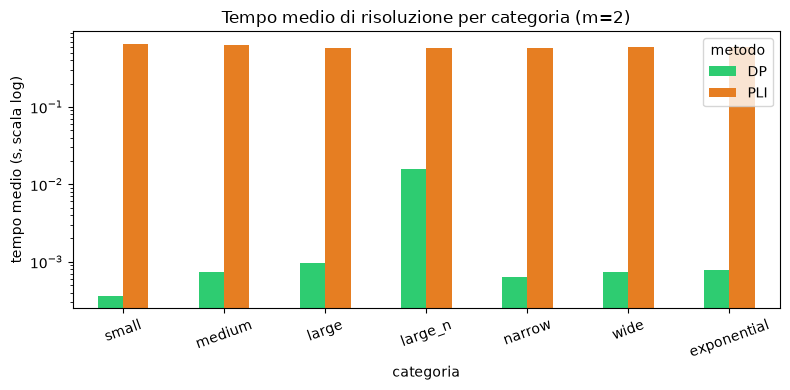

In [19]:
tempo_medio = riepilogo["tempo_medio_sec"].unstack().reindex(CATEGORIA_ORDINE)
tempo_medio.plot(kind="bar", figsize=(8, 4), color=[COLORI[m] for m in tempo_medio.columns], logy=True)
plt.ylabel("tempo medio (s, scala log)")
plt.title(f"Tempo medio di risoluzione per categoria (m={M})")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### Verifica incrociata

Su tutte le istanze risolte da entrambi i metodi, il C*_max deve coincidere esattamente
(sono entrambi metodi esatti, non euristiche).

In [20]:
solved = df[df.risolto]
confronto = solved.pivot_table(index="id", columns="metodo", values="cmax").dropna()
diversi = confronto[confronto["DP"] != confronto["PLI"]]

print(f"Istanze risolte da entrambi i metodi: {len(confronto)}")
if diversi.empty:
    print("Tutti i valori coincidono.")
else:
    print("ATTENZIONE, valori diversi:")
    print(diversi)

Istanze risolte da entrambi i metodi: 70
Tutti i valori coincidono.


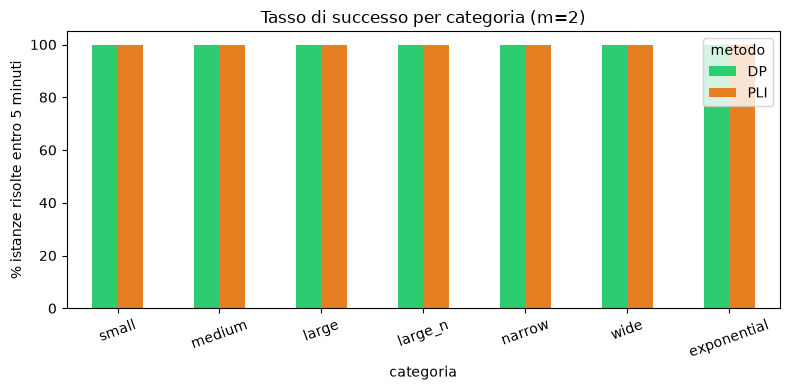

In [21]:
tasso = df.groupby(["categoria", "metodo"], observed=True)["risolto"].mean().unstack() * 100
tasso.plot(kind="bar", figsize=(8, 4), color=[COLORI[m] for m in tasso.columns])
plt.ylabel("% istanze risolte entro 5 minuti")
plt.title(f"Tasso di successo per categoria (m={M})")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

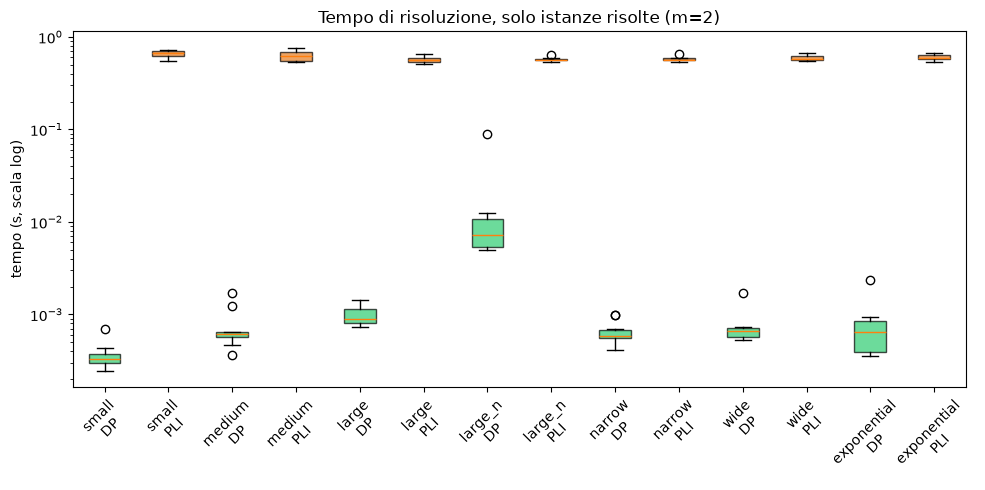

In [22]:
fig, ax = plt.subplots(figsize=(10, 5))
dati, etichette, colori = [], [], []
for cat in CATEGORIA_ORDINE:
    for metodo in ["DP", "PLI"]:
        sotto = solved[(solved["categoria"] == cat) & (solved["metodo"] == metodo)]
        if len(sotto):
            dati.append(sotto["tempo_sec"])
            etichette.append(f"{cat}\n{metodo}")
            colori.append(COLORI[metodo])

bp = ax.boxplot(dati, tick_labels=etichette, patch_artist=True)
for box, colore in zip(bp["boxes"], colori):
    box.set_facecolor(colore)
    box.set_alpha(0.7)

ax.set_yscale("log")
ax.set_ylabel("tempo (s, scala log)")
ax.set_title(f"Tempo di risoluzione, solo istanze risolte (m={M})")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

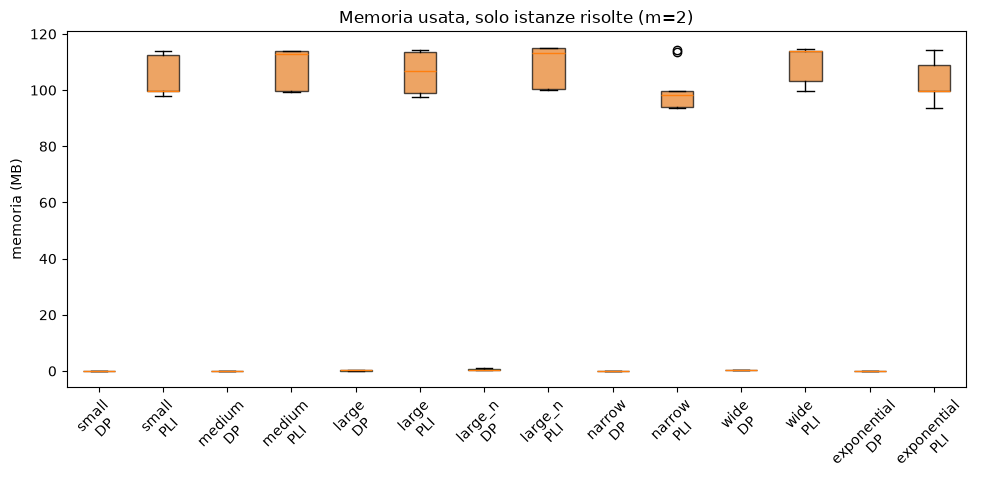

In [23]:
fig, ax = plt.subplots(figsize=(10, 5))
dati, etichette, colori = [], [], []
for cat in CATEGORIA_ORDINE:
    for metodo in ["DP", "PLI"]:
        sotto = solved[(solved["categoria"] == cat) & (solved["metodo"] == metodo)]
        if len(sotto):
            dati.append(sotto["memoria_mb"])
            etichette.append(f"{cat}\n{metodo}")
            colori.append(COLORI[metodo])

bp = ax.boxplot(dati, tick_labels=etichette, patch_artist=True)
for box, colore in zip(bp["boxes"], colori):
    box.set_facecolor(colore)
    box.set_alpha(0.7)

ax.set_ylabel("memoria (MB)")
ax.set_title(f"Memoria usata, solo istanze risolte (m={M})")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Seconda parte: stesso esperimento con m=3

Da qui in poi ripeto esattamente lo stesso esperimento (stesse categorie, stesse funzioni
`solve_dp`/`solve_pli`/`risolvi_con_limite` definite sopra, non le riscrivo), ma con **m=3**
invece di m=2. Uso nomi di variabili diversi (`istanze_m3`, `df_m3`, ...) cosi' non perdo i
risultati della prima parte e posso confrontarli.

In [24]:
M = 3  # da qui in poi lavoriamo con 3 macchine invece di 2

istanze_m3 = []
for cat in CATEGORIE:
    for i in range(N_ISTANZE):
        istanze_m3.append(genera_istanza(cat, i))

print(f"Generate {len(istanze_m3)} istanze (m={M})")
for ist in istanze_m3[::10]:
    print(ist["id"], "n=", ist["n"], "P=", sum(ist["p"]))

Generate 70 istanze (m=3)
small_00 n= 14 P= 706
medium_00 n= 24 P= 2469
large_00 n= 42 P= 6815
large_n_00 n= 594 P= 14775
narrow_00 n= 24 P= 1194
wide_00 n= 24 P= 13366
exponential_00 n= 24 P= 1460


In [25]:
risultati_m3 = []

In [26]:
# categoria: small
for ist in [i for i in istanze_m3 if i["categoria"] == "small"]:
    for nome_metodo, risolutore in METODI.items():
        print(f"{ist['id']:12s} {nome_metodo:4s} ... ", end="")
        cmax, stato, tempo, mem = risolutore(ist["n"], ist["m"], ist["p"])
        print(f"{stato:14s} cmax={cmax} tempo={tempo:.2f}s mem={mem:.1f}MB")
        risultati_m3.append({
            "id": ist["id"], "categoria": ist["categoria"], "n": ist["n"], "m": ist["m"],
            "P": sum(ist["p"]), "metodo": nome_metodo, "stato": stato, "cmax": cmax,
            "tempo_sec": tempo, "memoria_mb": mem,
        })

small_00     DP   ... OK             cmax=236 tempo=0.01s mem=6.9MB
small_00     PLI  ... OK             cmax=236 tempo=0.82s mem=115.9MB
small_01     DP   ... OK             cmax=198 tempo=0.00s mem=1.7MB
small_01     PLI  ... OK             cmax=198 tempo=0.86s mem=114.4MB
small_02     DP   ... OK             cmax=119 tempo=0.00s mem=0.5MB
small_02     PLI  ... OK             cmax=119 tempo=0.74s mem=113.9MB
small_03     DP   ... OK             cmax=206 tempo=0.00s mem=2.5MB
small_03     PLI  ... OK             cmax=206 tempo=0.84s mem=115.2MB
small_04     DP   ... OK             cmax=142 tempo=0.00s mem=2.2MB
small_04     PLI  ... OK             cmax=142 tempo=0.77s mem=114.5MB
small_05     DP   ... OK             cmax=255 tempo=0.01s mem=5.0MB
small_05     PLI  ... OK             cmax=255 tempo=0.80s mem=114.7MB
small_06     DP   ... OK             cmax=151 tempo=0.00s mem=1.0MB
small_06     PLI  ... OK             cmax=151 tempo=0.80s mem=114.3MB
small_07     DP   ... OK          

In [27]:
# categoria: medium
for ist in [i for i in istanze_m3 if i["categoria"] == "medium"]:
    for nome_metodo, risolutore in METODI.items():
        print(f"{ist['id']:12s} {nome_metodo:4s} ... ", end="")
        cmax, stato, tempo, mem = risolutore(ist["n"], ist["m"], ist["p"])
        print(f"{stato:14s} cmax={cmax} tempo={tempo:.2f}s mem={mem:.1f}MB")
        risultati_m3.append({
            "id": ist["id"], "categoria": ist["categoria"], "n": ist["n"], "m": ist["m"],
            "P": sum(ist["p"]), "metodo": nome_metodo, "stato": stato, "cmax": cmax,
            "tempo_sec": tempo, "memoria_mb": mem,
        })

medium_00    DP   ... OK             cmax=823 tempo=0.17s mem=106.7MB
medium_00    PLI  ... OK             cmax=823 tempo=0.68s mem=116.0MB
medium_01    DP   ... OK             cmax=751 tempo=0.08s mem=86.0MB
medium_01    PLI  ... OK             cmax=751 tempo=0.74s mem=116.1MB
medium_02    DP   ... OK             cmax=602 tempo=0.04s mem=51.8MB
medium_02    PLI  ... OK             cmax=602 tempo=0.65s mem=115.4MB
medium_03    DP   ... OK             cmax=778 tempo=0.07s mem=88.5MB
medium_03    PLI  ... OK             cmax=778 tempo=0.68s mem=115.9MB
medium_04    DP   ... OK             cmax=624 tempo=0.05s mem=64.0MB
medium_04    PLI  ... OK             cmax=624 tempo=0.65s mem=115.4MB
medium_05    DP   ... OK             cmax=924 tempo=0.23s mem=147.1MB
medium_05    PLI  ... OK             cmax=924 tempo=0.62s mem=115.7MB
medium_06    DP   ... OK             cmax=960 tempo=0.20s mem=166.8MB
medium_06    PLI  ... OK             cmax=960 tempo=0.67s mem=116.3MB
medium_07    DP   ... OK

In [28]:
# categoria: large
for ist in [i for i in istanze_m3 if i["categoria"] == "large"]:
    for nome_metodo, risolutore in METODI.items():
        print(f"{ist['id']:12s} {nome_metodo:4s} ... ", end="")
        cmax, stato, tempo, mem = risolutore(ist["n"], ist["m"], ist["p"])
        print(f"{stato:14s} cmax={cmax} tempo={tempo:.2f}s mem={mem:.1f}MB")
        risultati_m3.append({
            "id": ist["id"], "categoria": ist["categoria"], "n": ist["n"], "m": ist["m"],
            "P": sum(ist["p"]), "metodo": nome_metodo, "stato": stato, "cmax": cmax,
            "tempo_sec": tempo, "memoria_mb": mem,
        })

large_00     DP   ... OK             cmax=2272 tempo=2.44s mem=945.3MB
large_00     PLI  ... OK             cmax=2272 tempo=0.69s mem=117.4MB
large_01     DP   ... OK             cmax=1666 tempo=0.81s mem=517.3MB
large_01     PLI  ... OK             cmax=1666 tempo=0.63s mem=116.8MB
large_02     DP   ... OK             cmax=1649 tempo=0.71s mem=457.2MB
large_02     PLI  ... OK             cmax=1649 tempo=0.71s mem=117.6MB
large_03     DP   ... OK             cmax=2028 tempo=1.42s mem=749.1MB
large_03     PLI  ... OK             cmax=2028 tempo=0.64s mem=118.3MB
large_04     DP   ... OK             cmax=1704 tempo=0.86s mem=515.8MB
large_04     PLI  ... OK             cmax=1704 tempo=0.62s mem=117.2MB
large_05     DP   ... OK             cmax=2088 tempo=1.81s mem=813.9MB
large_05     PLI  ... OK             cmax=2088 tempo=0.64s mem=118.1MB
large_06     DP   ... OK             cmax=2420 tempo=2.89s mem=1086.1MB
large_06     PLI  ... OK             cmax=2420 tempo=0.71s mem=118.8MB
large

In [29]:
# categoria: large_n (quella lenta: con m=3 la DP puo' arrivare a qualche minuto per istanza,
# lo abbiamo gia' visto nel progetto "ufficiale" a moduli separati - fino a ~300s)
for ist in [i for i in istanze_m3 if i["categoria"] == "large_n"]:
    for nome_metodo, risolutore in METODI.items():
        print(f"{ist['id']:12s} {nome_metodo:4s} ... ", end="")
        cmax, stato, tempo, mem = risolutore(ist["n"], ist["m"], ist["p"])
        print(f"{stato:14s} cmax={cmax} tempo={tempo:.2f}s mem={mem:.1f}MB")
        risultati_m3.append({
            "id": ist["id"], "categoria": ist["categoria"], "n": ist["n"], "m": ist["m"],
            "P": sum(ist["p"]), "metodo": nome_metodo, "stato": stato, "cmax": cmax,
            "tempo_sec": tempo, "memoria_mb": mem,
        })

large_n_00   DP   ... OK             cmax=4925 tempo=107.04s mem=4581.1MB
large_n_00   PLI  ... OK             cmax=4925 tempo=0.90s mem=128.3MB
large_n_01   DP   ... OK             cmax=2882 tempo=22.66s mem=1568.6MB
large_n_01   PLI  ... OK             cmax=2882 tempo=0.70s mem=119.6MB
large_n_02   DP   ... OK             cmax=2197 tempo=7.58s mem=911.6MB
large_n_02   PLI  ... OK             cmax=2197 tempo=0.87s mem=124.8MB
large_n_03   DP   ... OK             cmax=3709 tempo=41.23s mem=2597.4MB
large_n_03   PLI  ... OK             cmax=3709 tempo=2.47s mem=128.7MB
large_n_04   DP   ... OK             cmax=3553 tempo=37.89s mem=2384.4MB
large_n_04   PLI  ... OK             cmax=3553 tempo=0.90s mem=125.8MB
large_n_05   DP   ... OK             cmax=7017 tempo=260.26s mem=9298.8MB
large_n_05   PLI  ... OK             cmax=7017 tempo=2.82s mem=135.3MB
large_n_06   DP   ... OK             cmax=6801 tempo=237.14s mem=8734.3MB
large_n_06   PLI  ... OK             cmax=6801 tempo=1.07s mem

In [30]:
# categoria: narrow
for ist in [i for i in istanze_m3 if i["categoria"] == "narrow"]:
    for nome_metodo, risolutore in METODI.items():
        print(f"{ist['id']:12s} {nome_metodo:4s} ... ", end="")
        cmax, stato, tempo, mem = risolutore(ist["n"], ist["m"], ist["p"])
        print(f"{stato:14s} cmax={cmax} tempo={tempo:.2f}s mem={mem:.1f}MB")
        risultati_m3.append({
            "id": ist["id"], "categoria": ist["categoria"], "n": ist["n"], "m": ist["m"],
            "P": sum(ist["p"]), "metodo": nome_metodo, "stato": stato, "cmax": cmax,
            "tempo_sec": tempo, "memoria_mb": mem,
        })

narrow_00    DP   ... OK             cmax=398 tempo=0.11s mem=13.0MB
narrow_00    PLI  ... OK             cmax=398 tempo=0.72s mem=116.8MB
narrow_01    DP   ... OK             cmax=340 tempo=0.01s mem=7.4MB
narrow_01    PLI  ... OK             cmax=340 tempo=0.92s mem=118.7MB
narrow_02    DP   ... OK             cmax=303 tempo=0.01s mem=6.2MB
narrow_02    PLI  ... OK             cmax=303 tempo=0.65s mem=116.1MB
narrow_03    DP   ... OK             cmax=359 tempo=0.01s mem=8.1MB
narrow_03    PLI  ... OK             cmax=359 tempo=0.58s mem=99.9MB
narrow_04    DP   ... OK             cmax=341 tempo=0.01s mem=7.2MB
narrow_04    PLI  ... OK             cmax=341 tempo=0.66s mem=116.0MB
narrow_05    DP   ... OK             cmax=444 tempo=0.02s mem=20.5MB
narrow_05    PLI  ... OK             cmax=444 tempo=0.61s mem=113.8MB
narrow_06    DP   ... OK             cmax=455 tempo=0.02s mem=22.6MB
narrow_06    PLI  ... OK             cmax=455 tempo=0.60s mem=99.7MB
narrow_07    DP   ... OK         

In [31]:
# categoria: wide
for ist in [i for i in istanze_m3 if i["categoria"] == "wide"]:
    for nome_metodo, risolutore in METODI.items():
        print(f"{ist['id']:12s} {nome_metodo:4s} ... ", end="")
        cmax, stato, tempo, mem = risolutore(ist["n"], ist["m"], ist["p"])
        print(f"{stato:14s} cmax={cmax} tempo={tempo:.2f}s mem={mem:.1f}MB")
        risultati_m3.append({
            "id": ist["id"], "categoria": ist["categoria"], "n": ist["n"], "m": ist["m"],
            "P": sum(ist["p"]), "metodo": nome_metodo, "stato": stato, "cmax": cmax,
            "tempo_sec": tempo, "memoria_mb": mem,
        })

wide_00      DP   ... OK             cmax=4456 tempo=5.77s mem=2671.1MB
wide_00      PLI  ... OK             cmax=4456 tempo=0.90s mem=117.3MB
wide_01      DP   ... OK             cmax=3405 tempo=3.08s mem=1426.6MB
wide_01      PLI  ... OK             cmax=3405 tempo=0.74s mem=115.8MB
wide_02      DP   ... OK             cmax=2752 tempo=1.61s mem=824.4MB
wide_02      PLI  ... OK             cmax=2752 tempo=0.80s mem=117.2MB
wide_03      DP   ... OK             cmax=3472 tempo=2.89s mem=1502.3MB
wide_03      PLI  ... OK             cmax=3472 tempo=0.98s mem=117.5MB
wide_04      DP   ... OK             cmax=2746 tempo=1.91s mem=985.0MB
wide_04      PLI  ... OK             cmax=2746 tempo=0.76s mem=117.6MB
wide_05      DP   ... OK             cmax=5118 tempo=7.95s mem=3938.2MB
wide_05      PLI  ... OK             cmax=5118 tempo=0.78s mem=117.9MB
wide_06      DP   ... OK             cmax=4608 tempo=6.78s mem=3406.6MB
wide_06      PLI  ... OK             cmax=4608 tempo=0.67s mem=117.2MB
w

In [32]:
# categoria: exponential
for ist in [i for i in istanze_m3 if i["categoria"] == "exponential"]:
    for nome_metodo, risolutore in METODI.items():
        print(f"{ist['id']:12s} {nome_metodo:4s} ... ", end="")
        cmax, stato, tempo, mem = risolutore(ist["n"], ist["m"], ist["p"])
        print(f"{stato:14s} cmax={cmax} t empo={tempo:.2f}s mem={mem:.1f}MB")
        risultati_m3.append({
            "id": ist["id"], "categoria": ist["categoria"], "n": ist["n"], "m": ist["m"],
            "P": sum(ist["p"]), "metodo": nome_metodo, "stato": stato, "cmax": cmax,
            "tempo_sec": tempo, "memoria_mb": mem,
        })

exponential_00 DP   ... OK             cmax=487 t empo=0.05s mem=40.9MB
exponential_00 PLI  ... OK             cmax=487 t empo=0.69s mem=112.5MB
exponential_01 DP   ... OK             cmax=263 t empo=0.01s mem=13.0MB
exponential_01 PLI  ... OK             cmax=263 t empo=0.62s mem=113.9MB
exponential_02 DP   ... OK             cmax=429 t empo=0.02s mem=33.3MB
exponential_02 PLI  ... OK             cmax=429 t empo=0.69s mem=115.9MB
exponential_03 DP   ... OK             cmax=340 t empo=0.02s mem=20.5MB
exponential_03 PLI  ... OK             cmax=340 t empo=0.62s mem=115.8MB
exponential_04 DP   ... OK             cmax=301 t empo=0.01s mem=17.1MB
exponential_04 PLI  ... OK             cmax=301 t empo=0.59s mem=114.5MB
exponential_05 DP   ... OK             cmax=402 t empo=0.02s mem=30.2MB
exponential_05 PLI  ... OK             cmax=402 t empo=0.64s mem=115.4MB
exponential_06 DP   ... OK             cmax=424 t empo=0.02s mem=32.4MB
exponential_06 PLI  ... OK             cmax=424 t empo=1.3

In [173]:
df_m3 = pd.DataFrame(risultati_m3)
df_m3["risolto"] = df_m3["stato"] == "OK"
df_m3["categoria"] = pd.Categorical(df_m3["categoria"], categories=CATEGORIA_ORDINE, ordered=True)
df_m3.to_csv(f"analysis/results_notebook_m{M}.csv", index=False)
df_m3.head(4)

,id,categoria,n,m,P,metodo,stato,cmax,tempo_sec,memoria_mb,risolto
0,small_00,small,14,3,706,DP,OK,236,0.007254,6.900910,True
1,small_00,small,14,3,706,PLI,OK,236,0.781636,116.023438,True
2,small_01,small,10,3,594,DP,OK,198,0.002229,1.708767,True
3,small_01,small,10,3,594,PLI,OK,198,0.812943,114.410156,True


## Analisi dei risultati (m=3)

In [174]:
riepilogo_m3 = df_m3.groupby(["categoria", "metodo"], observed=True).agg(
    risolte=("risolto", "sum"),
    totali=("risolto", "count"),
    tempo_medio_sec=("tempo_sec", "mean"),
    memoria_media_mb=("memoria_mb", "mean"),
)
riepilogo_m3

risolte  totali  tempo_medio_sec  memoria_media_mb
categoria   metodo                                                    
small       DP           10      10         0.003747          3.433610
            PLI          10      10         0.714340        113.112891
medium      DP           10      10         0.111117         96.141665
            PLI          10      10         0.662414        115.791016
large       DP           10      10         1.357897        706.389246
            PLI          10      10         0.652703        117.761719
large_n     DP           10      10        97.890446       4189.509250
            PLI          10      10         1.524937        129.356250
narrow      DP           10      10         0.016019         12.285396
            PLI          10      10         0.849349        113.506641
wide        DP           10      10         4.116901       1967.086365
            PLI          10      10         0.962704        117.565234
exponential DP           10      10         0.023314         27.082146
            PLI          10      10         0.734123        113.893359

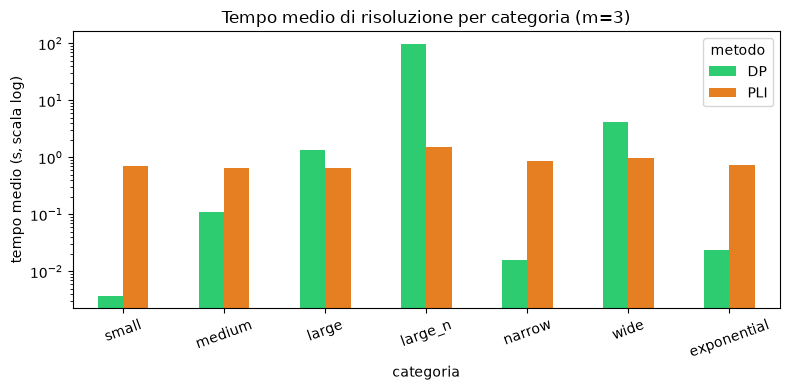

In [175]:
tempo_medio_m3 = riepilogo_m3["tempo_medio_sec"].unstack().reindex(CATEGORIA_ORDINE)
tempo_medio_m3.plot(kind="bar", figsize=(8, 4), color=[COLORI[m] for m in tempo_medio_m3.columns], logy=True)
plt.ylabel("tempo medio (s, scala log)")
plt.title(f"Tempo medio di risoluzione per categoria (m={M})")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [176]:
solved_m3 = df_m3[df_m3.risolto]
confronto_m3 = solved_m3.pivot_table(index="id", columns="metodo", values="cmax").dropna()
diversi_m3 = confronto_m3[confronto_m3["DP"] != confronto_m3["PLI"]]

print(f"Istanze risolte da entrambi i metodi: {len(confronto_m3)}")
if diversi_m3.empty:
    print("Tutti i valori coincidono.")
else:
    print("ATTENZIONE, valori diversi:")
    print(diversi_m3)

Istanze risolte da entrambi i metodi: 70
Tutti i valori coincidono.


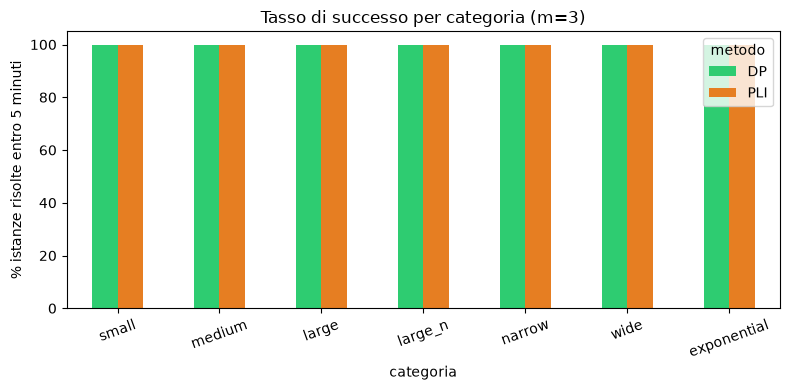

In [177]:
tasso_m3 = df_m3.groupby(["categoria", "metodo"], observed=True)["risolto"].mean().unstack() * 100
tasso_m3.plot(kind="bar", figsize=(8, 4), color=[COLORI[m] for m in tasso_m3.columns])
plt.ylabel("% istanze risolte entro 5 minuti")
plt.title(f"Tasso di successo per categoria (m={M})")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

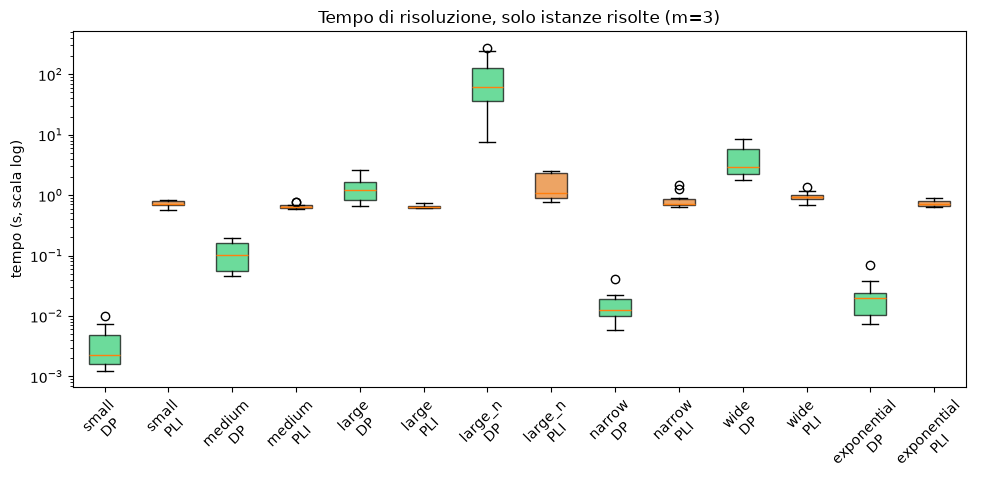

In [178]:
fig, ax = plt.subplots(figsize=(10, 5))
dati, etichette, colori = [], [], []
for cat in CATEGORIA_ORDINE:
    for metodo in ["DP", "PLI"]:
        sotto = solved_m3[(solved_m3["categoria"] == cat) & (solved_m3["metodo"] == metodo)]
        if len(sotto):
            dati.append(sotto["tempo_sec"])
            etichette.append(f"{cat}\n{metodo}")
            colori.append(COLORI[metodo])

bp = ax.boxplot(dati, tick_labels=etichette, patch_artist=True)
for box, colore in zip(bp["boxes"], colori):
    box.set_facecolor(colore)
    box.set_alpha(0.7)

ax.set_yscale("log")
ax.set_ylabel("tempo (s, scala log)")
ax.set_title(f"Tempo di risoluzione, solo istanze risolte (m={M})")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

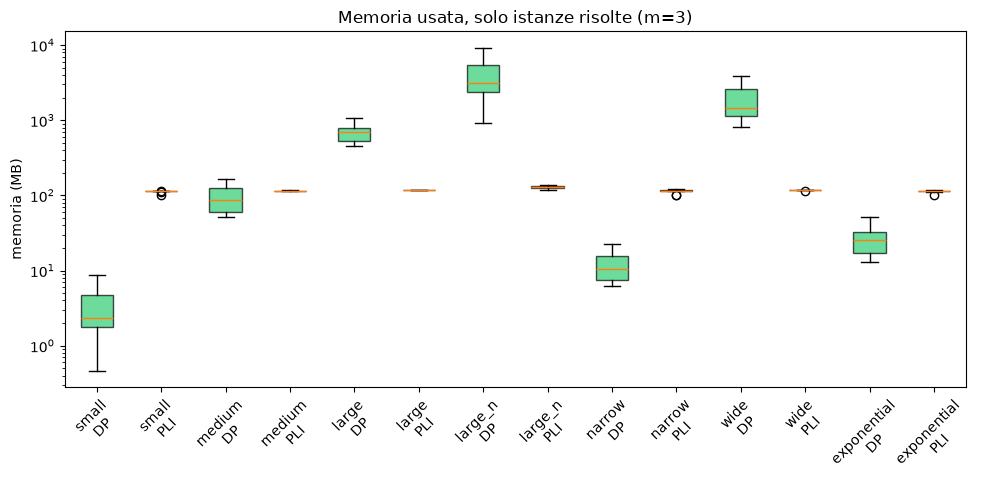

In [181]:
fig, ax = plt.subplots(figsize=(10, 5))
dati, etichette, colori = [], [], []
for cat in CATEGORIA_ORDINE:
    for metodo in ["DP", "PLI"]:
        sotto = solved_m3[(solved_m3["categoria"] == cat) & (solved_m3["metodo"] == metodo)]
        if len(sotto):
            dati.append(sotto["memoria_mb"])
            etichette.append(f"{cat}\n{metodo}")
            colori.append(COLORI[metodo])

bp = ax.boxplot(dati, tick_labels=etichette, patch_artist=True)
for box, colore in zip(bp["boxes"], colori):
    box.set_facecolor(colore)
    box.set_alpha(0.7)

ax.set_ylabel("memoria (MB)")
ax.set_yscale("log")
ax.set_title(f"Memoria usata, solo istanze risolte (m={M})")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Terza parte: stesso esperimento con m=4

Ancora la stessa struttura, ora con **m=4**. La guardia di memoria della DP scatta quando
`(P+1)^(m-1)` supera la soglia: a m=4 il punto critico e' P ~ 1.000. Guardando i valori di P
delle nostre categorie (li abbiamo visti nelle sezioni precedenti), ci aspettiamo qualcosa di
diverso da m=3:

- `small` (P~350-750): dovrebbe restare **sotto** soglia, la DP dovrebbe farcela ancora
- `narrow` (P~1.100-1.300) ed `exponential` (P~1.000-1.500): **proprio a cavallo** della soglia,
  possibile un mix di istanze che passano e istanze che falliscono
- `medium`/`large`/`large_n`/`wide`: ben sopra soglia, ci aspettiamo che falliscano quasi tutte

E' il motivo per cui m=4 e' piu' interessante di m=5 o m=6: a m=5 la soglia scende a ~177,
sotto il P minimo che abbiamo in assoluto - la DP fallirebbe ovunque, senza nessuna
differenziazione tra categorie.

In [9]:
M = 4  # da qui in poi lavoriamo con 4 macchine
SOGLIA_MEMORIA = 1_000_000_000


istanze_m4 = []
for cat in CATEGORIE:
    for i in range(N_ISTANZE):
        istanze_m4.append(genera_istanza(cat, i))

print(f"Generate {len(istanze_m4)} istanze (m={M})")
for ist in istanze_m4[::10]:
    print(ist["id"], "n=", ist["n"], "P=", sum(ist["p"]))

Generate 70 istanze (m=4)
small_00 n= 14 P= 706
medium_00 n= 24 P= 2469
large_00 n= 42 P= 6815
large_n_00 n= 594 P= 14775
narrow_00 n= 24 P= 1194
wide_00 n= 24 P= 13366
exponential_00 n= 24 P= 1460


In [10]:
risultati_m4 = []

In [11]:
# categoria: small
for ist in [i for i in istanze_m4 if i["categoria"] == "small"]:
    for nome_metodo, risolutore in METODI.items():
        print(f"{ist['id']:12s} {nome_metodo:4s} ... ", end="")
        cmax, stato, tempo, mem = risolutore(ist["n"], ist["m"], ist["p"])
        print(f"{stato:14s} cmax={cmax} tempo={tempo:.2f}s mem={mem:.1f}MB")
        risultati_m4.append({
            "id": ist["id"], "categoria": ist["categoria"], "n": ist["n"], "m": ist["m"],
            "P": sum(ist["p"]), "metodo": nome_metodo, "stato": stato, "cmax": cmax,
            "tempo_sec": tempo, "memoria_mb": mem,
        })

small_00     DP   ... OK             cmax=177 tempo=7.14s mem=1615.6MB
small_00     PLI  ... OK             cmax=177 tempo=0.85s mem=117.5MB
small_01     DP   ... OK             cmax=156 tempo=2.31s mem=425.4MB
small_01     PLI  ... OK             cmax=156 tempo=0.65s mem=115.2MB
small_02     DP   ... OK             cmax=95 tempo=0.39s mem=82.3MB
small_02     PLI  ... OK             cmax=95 tempo=0.64s mem=114.6MB
small_03     DP   ... OK             cmax=151 tempo=2.54s mem=468.0MB
small_03     PLI  ... OK             cmax=151 tempo=0.68s mem=114.8MB
small_04     DP   ... OK             cmax=110 tempo=1.02s mem=229.2MB
small_04     PLI  ... OK             cmax=110 tempo=0.68s mem=115.7MB
small_05     DP   ... OK             cmax=193 tempo=5.83s mem=1040.4MB
small_05     PLI  ... OK             cmax=193 tempo=0.68s mem=115.7MB
small_06     DP   ... OK             cmax=124 tempo=0.86s mem=176.2MB
small_06     PLI  ... OK             cmax=124 tempo=0.66s mem=114.8MB
small_07     DP   ...

In [12]:
# categoria: medium
for ist in [i for i in istanze_m4 if i["categoria"] == "medium"]:
    for nome_metodo, risolutore in METODI.items():
        print(f"{ist['id']:12s} {nome_metodo:4s} ... ", end="")
        cmax, stato, tempo, mem = risolutore(ist["n"], ist["m"], ist["p"])
        print(f"{stato:14s} cmax={cmax} tempo={tempo:.2f}s mem={mem:.1f}MB")
        risultati_m4.append({
            "id": ist["id"], "categoria": ist["categoria"], "n": ist["n"], "m": ist["m"],
            "P": sum(ist["p"]), "metodo": nome_metodo, "stato": stato, "cmax": cmax,
            "tempo_sec": tempo, "memoria_mb": mem,
        })

medium_00    DP   ... MEMORY_GUARD   cmax=None tempo=0.00s mem=0.0MB
medium_00    PLI  ... OK             cmax=618 tempo=0.84s mem=117.6MB
medium_01    DP   ... MEMORY_GUARD   cmax=None tempo=0.00s mem=0.0MB
medium_01    PLI  ... OK             cmax=563 tempo=0.99s mem=119.1MB
medium_02    DP   ... MEMORY_GUARD   cmax=None tempo=0.00s mem=0.0MB
medium_02    PLI  ... OK             cmax=452 tempo=0.99s mem=119.0MB
medium_03    DP   ... MEMORY_GUARD   cmax=None tempo=0.00s mem=0.0MB
medium_03    PLI  ... OK             cmax=583 tempo=0.82s mem=117.0MB
medium_04    DP   ... MEMORY_GUARD   cmax=None tempo=0.00s mem=0.0MB
medium_04    PLI  ... OK             cmax=468 tempo=1.23s mem=117.1MB
medium_05    DP   ... MEMORY_GUARD   cmax=None tempo=0.00s mem=0.0MB
medium_05    PLI  ... OK             cmax=693 tempo=1.64s mem=117.4MB
medium_06    DP   ... MEMORY_GUARD   cmax=None tempo=0.00s mem=0.0MB
medium_06    PLI  ... OK             cmax=720 tempo=2.25s mem=119.5MB
medium_07    DP   ... MEMOR

In [13]:
# categoria: large
for ist in [i for i in istanze_m4 if i["categoria"] == "large"]:
    for nome_metodo, risolutore in METODI.items():
        print(f"{ist['id']:12s} {nome_metodo:4s} ... ", end="")
        cmax, stato, tempo, mem = risolutore(ist["n"], ist["m"], ist["p"])
        print(f"{stato:14s} cmax={cmax} tempo={tempo:.2f}s mem={mem:.1f}MB")
        risultati_m4.append({
            "id": ist["id"], "categoria": ist["categoria"], "n": ist["n"], "m": ist["m"],
            "P": sum(ist["p"]), "metodo": nome_metodo, "stato": stato, "cmax": cmax,
            "tempo_sec": tempo, "memoria_mb": mem,
        })

large_00     DP   ... MEMORY_GUARD   cmax=None tempo=0.00s mem=0.0MB
large_00     PLI  ... OK             cmax=1704 tempo=1.30s mem=124.6MB
large_01     DP   ... MEMORY_GUARD   cmax=None tempo=0.00s mem=0.0MB
large_01     PLI  ... OK             cmax=1250 tempo=1.14s mem=119.2MB
large_02     DP   ... MEMORY_GUARD   cmax=None tempo=0.00s mem=0.0MB
large_02     PLI  ... OK             cmax=1237 tempo=1.38s mem=121.1MB
large_03     DP   ... MEMORY_GUARD   cmax=None tempo=0.00s mem=0.0MB
large_03     PLI  ... OK             cmax=1521 tempo=1.78s mem=124.5MB
large_04     DP   ... MEMORY_GUARD   cmax=None tempo=0.00s mem=0.0MB
large_04     PLI  ... OK             cmax=1278 tempo=0.96s mem=118.2MB
large_05     DP   ... MEMORY_GUARD   cmax=None tempo=0.00s mem=0.0MB
large_05     PLI  ... OK             cmax=1566 tempo=0.87s mem=118.3MB
large_06     DP   ... MEMORY_GUARD   cmax=None tempo=0.00s mem=0.0MB
large_06     PLI  ... OK             cmax=1815 tempo=1.32s mem=123.3MB
large_07     DP   ..

In [14]:
# categoria: large_n
for ist in [i for i in istanze_m4 if i["categoria"] == "large_n"]:
    for nome_metodo, risolutore in METODI.items():
        print(f"{ist['id']:12s} {nome_metodo:4s} ... ", end="")
        cmax, stato, tempo, mem = risolutore(ist["n"], ist["m"], ist["p"])
        print(f"{stato:14s} cmax={cmax} tempo={tempo:.2f}s mem={mem:.1f}MB")
        risultati_m4.append({
            "id": ist["id"], "categoria": ist["categoria"], "n": ist["n"], "m": ist["m"],
            "P": sum(ist["p"]), "metodo": nome_metodo, "stato": stato, "cmax": cmax,
            "tempo_sec": tempo, "memoria_mb": mem,
        })

large_n_00   DP   ... MEMORY_GUARD   cmax=None tempo=0.00s mem=0.0MB
large_n_00   PLI  ... OK             cmax=3694 tempo=1.52s mem=138.1MB
large_n_01   DP   ... MEMORY_GUARD   cmax=None tempo=0.00s mem=0.0MB
large_n_01   PLI  ... OK             cmax=2162 tempo=1.84s mem=142.8MB
large_n_02   DP   ... MEMORY_GUARD   cmax=None tempo=0.00s mem=0.0MB
large_n_02   PLI  ... OK             cmax=1648 tempo=1.01s mem=125.4MB
large_n_03   DP   ... MEMORY_GUARD   cmax=None tempo=0.00s mem=0.0MB
large_n_03   PLI  ... OK             cmax=2782 tempo=1.08s mem=132.1MB
large_n_04   DP   ... MEMORY_GUARD   cmax=None tempo=0.00s mem=0.0MB
large_n_04   PLI  ... OK             cmax=2665 tempo=1.03s mem=124.2MB
large_n_05   DP   ... MEMORY_GUARD   cmax=None tempo=0.00s mem=0.0MB
large_n_05   PLI  ... OK             cmax=5263 tempo=2.06s mem=150.1MB
large_n_06   DP   ... MEMORY_GUARD   cmax=None tempo=0.00s mem=0.0MB
large_n_06   PLI  ... OK             cmax=5101 tempo=1.65s mem=147.7MB
large_n_07   DP   ..

In [15]:
# categoria: narrow
for ist in [i for i in istanze_m4 if i["categoria"] == "narrow"]:
    for nome_metodo, risolutore in METODI.items():
        print(f"{ist['id']:12s} {nome_metodo:4s} ... ", end="")
        cmax, stato, tempo, mem = risolutore(ist["n"], ist["m"], ist["p"])
        print(f"{stato:14s} cmax={cmax} tempo={tempo:.2f}s mem={mem:.1f}MB")
        risultati_m4.append({
            "id": ist["id"], "categoria": ist["categoria"], "n": ist["n"], "m": ist["m"],
            "P": sum(ist["p"]), "metodo": nome_metodo, "stato": stato, "cmax": cmax,
            "tempo_sec": tempo, "memoria_mb": mem,
        })

narrow_00    DP   ... MEMORY_GUARD   cmax=None tempo=0.00s mem=0.0MB
narrow_00    PLI  ... OK             cmax=299 tempo=0.66s mem=116.1MB
narrow_01    DP   ... OK             cmax=250 tempo=20.74s mem=2541.2MB
narrow_01    PLI  ... OK             cmax=250 tempo=0.70s mem=117.1MB
narrow_02    DP   ... OK             cmax=239 tempo=14.51s mem=1922.3MB
narrow_02    PLI  ... OK             cmax=239 tempo=1.33s mem=121.6MB
narrow_03    DP   ... MEMORY_GUARD   cmax=None tempo=0.00s mem=0.0MB
narrow_03    PLI  ... OK             cmax=283 tempo=1.11s mem=120.1MB
narrow_04    DP   ... MEMORY_GUARD   cmax=None tempo=0.00s mem=0.0MB
narrow_04    PLI  ... OK             cmax=274 tempo=1.87s mem=123.5MB
narrow_05    DP   ... MEMORY_GUARD   cmax=None tempo=0.00s mem=0.0MB
narrow_05    PLI  ... OK             cmax=337 tempo=1.81s mem=122.1MB
narrow_06    DP   ... MEMORY_GUARD   cmax=None tempo=0.00s mem=0.0MB
narrow_06    PLI  ... OK             cmax=346 tempo=1.68s mem=121.6MB
narrow_07    DP   ...

In [16]:
# categoria: wide
for ist in [i for i in istanze_m4 if i["categoria"] == "wide"]:
    for nome_metodo, risolutore in METODI.items():
        print(f"{ist['id']:12s} {nome_metodo:4s} ... ", end="")
        cmax, stato, tempo, mem = risolutore(ist["n"], ist["m"], ist["p"])
        print(f"{stato:14s} cmax={cmax} tempo={tempo:.2f}s mem={mem:.1f}MB")
        risultati_m4.append({
            "id": ist["id"], "categoria": ist["categoria"], "n": ist["n"], "m": ist["m"],
            "P": sum(ist["p"]), "metodo": nome_metodo, "stato": stato, "cmax": cmax,
            "tempo_sec": tempo, "memoria_mb": mem,
        })

wide_00      DP   ... MEMORY_GUARD   cmax=None tempo=0.00s mem=0.0MB
wide_00      PLI  ... OK             cmax=3342 tempo=4.09s mem=124.4MB
wide_01      DP   ... MEMORY_GUARD   cmax=None tempo=0.00s mem=0.0MB
wide_01      PLI  ... OK             cmax=2554 tempo=8.47s mem=130.1MB
wide_02      DP   ... MEMORY_GUARD   cmax=None tempo=0.00s mem=0.0MB
wide_02      PLI  ... OK             cmax=2065 tempo=8.42s mem=126.9MB
wide_03      DP   ... MEMORY_GUARD   cmax=None tempo=0.00s mem=0.0MB
wide_03      PLI  ... OK             cmax=2604 tempo=2.00s mem=122.7MB
wide_04      DP   ... MEMORY_GUARD   cmax=None tempo=0.00s mem=0.0MB
wide_04      PLI  ... OK             cmax=2059 tempo=2.79s mem=124.5MB
wide_05      DP   ... MEMORY_GUARD   cmax=None tempo=0.00s mem=0.0MB
wide_05      PLI  ... OK             cmax=3839 tempo=1.55s mem=121.5MB
wide_06      DP   ... MEMORY_GUARD   cmax=None tempo=0.00s mem=0.0MB
wide_06      PLI  ... OK             cmax=3456 tempo=1.47s mem=120.1MB
wide_07      DP   ..

In [17]:
# categoria: exponential
for ist in [i for i in istanze_m4 if i["categoria"] == "exponential"]:
    for nome_metodo, risolutore in METODI.items():
        print(f"{ist['id']:12s} {nome_metodo:4s} ... ", end="")
        cmax, stato, tempo, mem = risolutore(ist["n"], ist["m"], ist["p"])
        print(f"{stato:14s} cmax={cmax} tempo={tempo:.2f}s mem={mem:.1f}MB")
        risultati_m4.append({
            "id": ist["id"], "categoria": ist["categoria"], "n": ist["n"], "m": ist["m"],
            "P": sum(ist["p"]), "metodo": nome_metodo, "stato": stato, "cmax": cmax,
            "tempo_sec": tempo, "memoria_mb": mem,
        })

exponential_00 DP   ... MEMORY_GUARD   cmax=None tempo=0.00s mem=0.0MB
exponential_00 PLI  ... OK             cmax=365 tempo=0.88s mem=119.4MB
exponential_01 DP   ... OK             cmax=197 tempo=13.30s mem=4607.5MB
exponential_01 PLI  ... OK             cmax=197 tempo=0.73s mem=118.4MB
exponential_02 DP   ... MEMORY_GUARD   cmax=None tempo=0.00s mem=0.0MB
exponential_02 PLI  ... OK             cmax=409 tempo=0.62s mem=112.4MB
exponential_03 DP   ... MEMORY_GUARD   cmax=None tempo=0.00s mem=0.0MB
exponential_03 PLI  ... OK             cmax=255 tempo=0.68s mem=116.3MB
exponential_04 DP   ... OK             cmax=230 tempo=20.47s mem=6985.9MB
exponential_04 PLI  ... OK             cmax=230 tempo=1.12s mem=114.7MB
exponential_05 DP   ... MEMORY_GUARD   cmax=None tempo=0.00s mem=0.0MB
exponential_05 PLI  ... OK             cmax=302 tempo=1.07s mem=116.2MB
exponential_06 DP   ... MEMORY_GUARD   cmax=None tempo=0.00s mem=0.0MB
exponential_06 PLI  ... OK             cmax=318 tempo=1.60s mem=1

In [18]:
df_m4 = pd.DataFrame(risultati_m4)
df_m4["risolto"] = df_m4["stato"] == "OK"
df_m4["categoria"] = pd.Categorical(df_m4["categoria"], categories=CATEGORIA_ORDINE, ordered=True)
df_m4.to_csv(f"analysis/results_notebook_m{M}.csv", index=False)
df_m4.head(4)

,id,categoria,n,m,P,metodo,stato,cmax,tempo_sec,memoria_mb,risolto
0,small_00,small,14,4,706,DP,OK,177.0,7.137098,1615.551866,True
1,small_00,small,14,4,706,PLI,OK,177.0,0.845340,117.464844,True
2,small_01,small,10,4,594,DP,OK,156.0,2.312782,425.368721,True
3,small_01,small,10,4,594,PLI,OK,156.0,0.649780,115.222656,True


## Analisi dei risultati (m=4)

In [19]:
riepilogo_m4 = df_m4.groupby(["categoria", "metodo"], observed=True).agg(
    risolte=("risolto", "sum"),
    totali=("risolto", "count"),
    tempo_medio_sec=("tempo_sec", "mean"),
    memoria_media_mb=("memoria_mb", "mean"),
)
riepilogo_m4

risolte  totali  tempo_medio_sec  memoria_media_mb
categoria   metodo                                                    
small       DP           10      10         3.065506        711.361924
            PLI          10      10         0.683118        115.397656
medium      DP            0      10         0.000012          0.000425
            PLI          10      10         1.372872        118.410547
large       DP            0      10         0.000012          0.000425
            PLI          10      10         1.239244        121.286719
large_n     DP            0      10         0.000012          0.000425
            PLI          10      10         1.575964        137.635156
narrow      DP            2      10         3.525527        446.342862
            PLI          10      10         1.436598        121.410547
wide        DP            0      10         0.000009          0.000425
            PLI          10      10         3.479568        123.441406
exponential DP            4      10         8.257935       2460.621337
            PLI          10      10         0.998201        116.485938

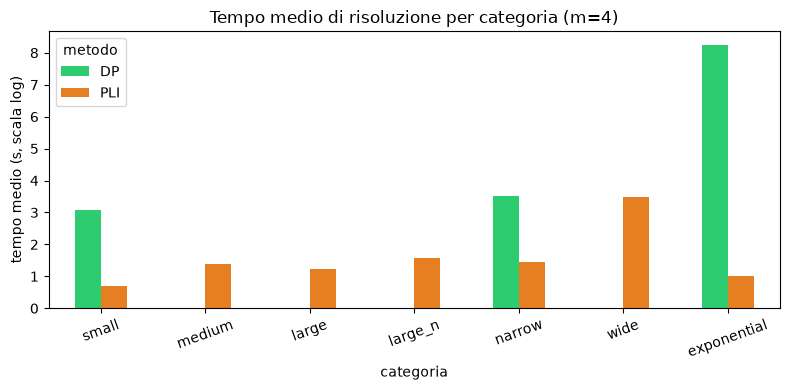

In [21]:
tempo_medio_m4 = riepilogo_m4["tempo_medio_sec"].unstack().reindex(CATEGORIA_ORDINE)
tempo_medio_m4.plot(kind="bar", figsize=(8, 4), color=[COLORI[m] for m in tempo_medio_m4.columns], logy=False)
plt.ylabel("tempo medio (s, scala log)")
plt.title(f"Tempo medio di risoluzione per categoria (m={M})")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### Verifica incrociata (m=4)

In [22]:
solved_m4 = df_m4[df_m4.risolto]
confronto_m4 = solved_m4.pivot_table(index="id", columns="metodo", values="cmax").dropna()
diversi_m4 = confronto_m4[confronto_m4["DP"] != confronto_m4["PLI"]]

print(f"Istanze risolte da entrambi i metodi: {len(confronto_m4)}")
if diversi_m4.empty:
    print("Tutti i valori coincidono.")
else:
    print("ATTENZIONE, valori diversi:")
    print(diversi_m4)

Istanze risolte da entrambi i metodi: 16
Tutti i valori coincidono.


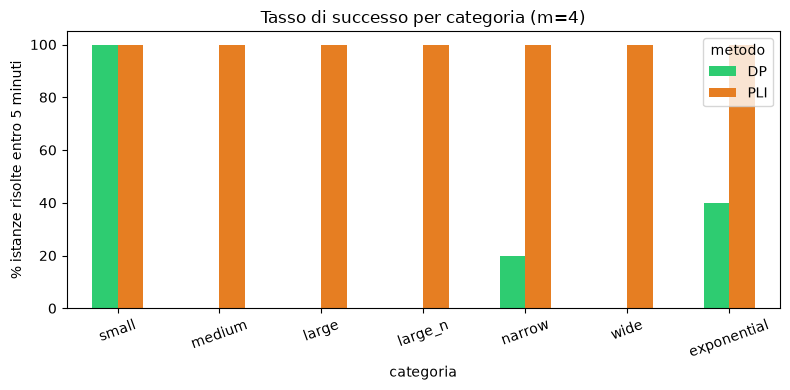

In [23]:
tasso_m4 = df_m4.groupby(["categoria", "metodo"], observed=True)["risolto"].mean().unstack() * 100
tasso_m4.plot(kind="bar", figsize=(8, 4), color=[COLORI[m] for m in tasso_m4.columns])
plt.ylabel("% istanze risolte entro 5 minuti")
plt.title(f"Tasso di successo per categoria (m={M})")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

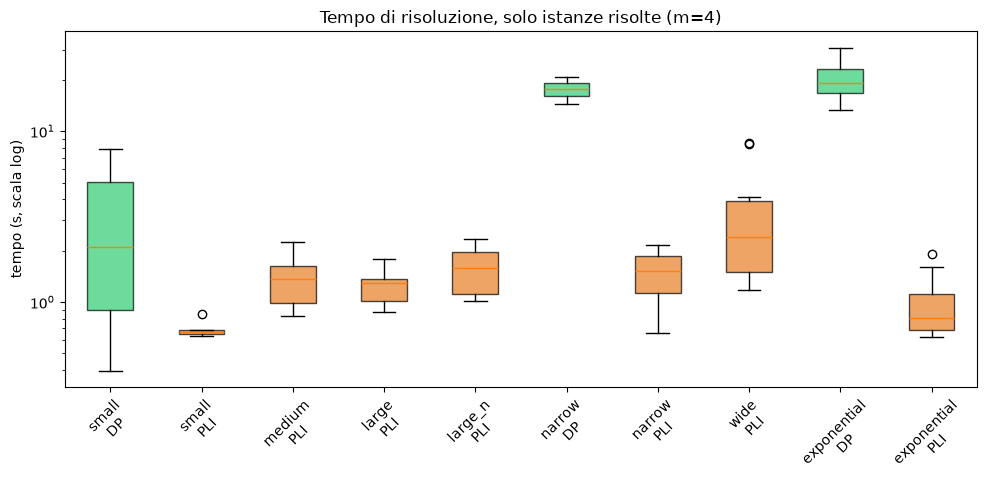

In [24]:
fig, ax = plt.subplots(figsize=(10, 5))
dati, etichette, colori = [], [], []
for cat in CATEGORIA_ORDINE:
    for metodo in ["DP", "PLI"]:
        sotto = solved_m4[(solved_m4["categoria"] == cat) & (solved_m4["metodo"] == metodo)]
        if len(sotto):
            dati.append(sotto["tempo_sec"])
            etichette.append(f"{cat}\n{metodo}")
            colori.append(COLORI[metodo])

bp = ax.boxplot(dati, tick_labels=etichette, patch_artist=True)
for box, colore in zip(bp["boxes"], colori):
    box.set_facecolor(colore)
    box.set_alpha(0.7)

ax.set_yscale("log")
ax.set_ylabel("tempo (s, scala log)")
ax.set_title(f"Tempo di risoluzione, solo istanze risolte (m={M})")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

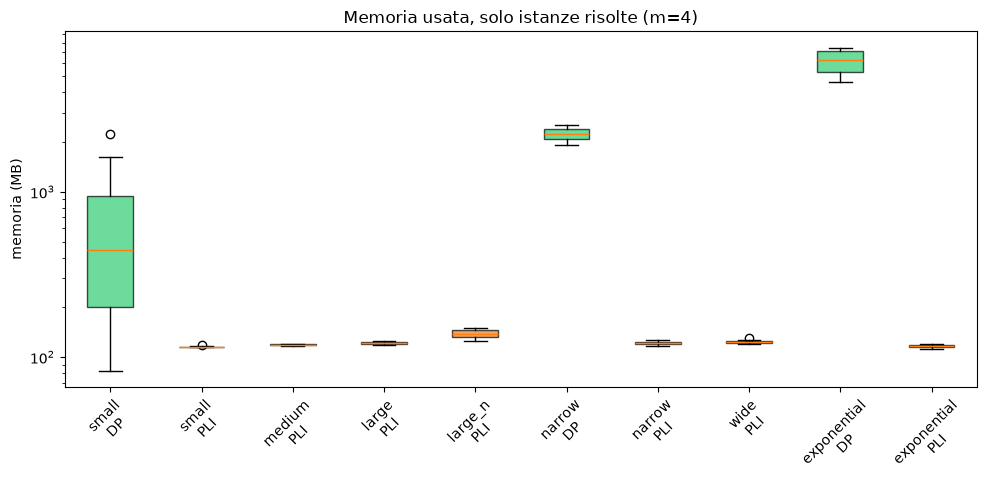

In [25]:
fig, ax = plt.subplots(figsize=(10, 5))
dati, etichette, colori = [], [], []
for cat in CATEGORIA_ORDINE:
    for metodo in ["DP", "PLI"]:
        sotto = solved_m4[(solved_m4["categoria"] == cat) & (solved_m4["metodo"] == metodo)]
        if len(sotto):
            dati.append(sotto["memoria_mb"])
            etichette.append(f"{cat}\n{metodo}")
            colori.append(COLORI[metodo])

bp = ax.boxplot(dati, tick_labels=etichette, patch_artist=True)
for box, colore in zip(bp["boxes"], colori):
    box.set_facecolor(colore)
    box.set_alpha(0.7)

ax.set_ylabel("memoria (MB)")
ax.set_yscale("log")
ax.set_title(f"Memoria usata, solo istanze risolte (m={M})")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Salvataggio e ricaricamento dei dati

Le due celle sotto servono a non dover rieseguire tutto il benchmark (in particolare le
categorie `large_n`, che possono metterci diversi minuti) ogni volta che si riapre il notebook.

Uso `pickle`, il modo piu' diretto in Python per salvare "qualsiasi cosa" - una lista, un
DataFrame, un dizionario - in un unico file, senza dover inventare un formato apposta per
ognuno. Dentro ci metto tutto quello che serve per rifare tabelle e grafici senza rilanciare
i solutori: le istanze generate, i DataFrame `df`/`df_m3` con tutti i risultati, i riepiloghi,
e la configurazione (categorie, ordine, colori).

Dopo aver ricaricato, se vuoi rivedere tabelle/grafici basta tornare su alle celle di analisi
(`riepilogo`, verifica incrociata, grafici) e rieseguirle - sono veloci, lavorano solo sui
DataFrame gia' pronti, non richiamano ne' la DP ne' il PLI.

In [26]:
import pickle

dati_da_salvare = {
    "CATEGORIE": CATEGORIE,
    "CATEGORIA_ORDINE": CATEGORIA_ORDINE,
    "COLORI": COLORI,
    "istanze": istanze,
    "istanze_m3": istanze_m3,
    "istanze_m4": istanze_m4,
    "df": df,
    "df_m3": df_m3,
    "df_m4": df_m4,
    "riepilogo": riepilogo,
    "riepilogo_m3": riepilogo_m3,
    "riepilogo_m4": riepilogo_m4,
}

with open("analysis/dati_notebook.pkl", "wb") as f:
    pickle.dump(dati_da_salvare, f)

print(f"Salvati {len(dati_da_salvare)} elementi in analysis/dati_notebook.pkl")

NameError: name 'istanze_m3' is not defined

In [ ]:
import pickle

with open("analysis/dati_notebook.pkl", "rb") as f:
    dati_caricati = pickle.load(f)

CATEGORIE = dati_caricati["CATEGORIE"]
CATEGORIA_ORDINE = dati_caricati["CATEGORIA_ORDINE"]
COLORI = dati_caricati["COLORI"]
istanze = dati_caricati["istanze"]
istanze_m3 = dati_caricati["istanze_m3"]
istanze_m4 = dati_caricati["istanze_m4"]
df = dati_caricati["df"]
df_m3 = dati_caricati["df_m3"]
df_m4 = dati_caricati["df_m4"]
riepilogo = dati_caricati["riepilogo"]
riepilogo_m3 = dati_caricati["riepilogo_m3"]
riepilogo_m4 = dati_caricati["riepilogo_m4"]

print("Dati ricaricati da analysis/dati_notebook.pkl")
df.head()

# Conclusioni

## m e' il fattore che decide tutto per la DP, non n

La memoria (e il tempo) della DP dipendono da `(P+1)^(m-1)` - **m all'esponente**, P solo alla
base. I nostri numeri reali lo confermano passo per passo:

| m | esito DP |
|---|---|
| 2 | tutte le 7 categorie risolte, sempre sotto 0.5MB e pochi millisecondi |
| 3 | tutte risolte ancora, ma con costi molto piu' vari: da 3.4MB (`small`) a **4,2 GB** (`large_n`, fino a ~300s nel caso peggiore osservato) |
| 4 | crollo netto: `small` sopravvive (10/10, ma ora 3s e 711MB - molto piu' caro che a m=3), `narrow` e `exponential` diventano **parziali** (2/10 e 4/10: proprio il comportamento "a cavallo della soglia" previsto), le altre 4 categorie falliscono sempre (0/10) |

Un aumento di m moltiplica la dimensione dello stato per un intero fattore P in piu' - un
aumento di n, da solo, non tocca affatto la dimensione dello stato, solo quante volte lo
aggiorniamo (`large_n` a m=2 resta banale nonostante n fino a 1000, proprio perche' li' P e'
tenuto basso apposta).

## Il PLI e' rimasto solido su tutte e tre le sezioni

Su ogni singola categoria, a ogni m testato (2, 3, 4), il PLI ha risolto **10 istanze su 10**,
quasi sempre in meno di 1-3 secondi - anche quando la DP falliva completamente. A m=4 il tempo
medio del PLI resta fra 0.7 e 3.2 secondi su tutte le 7 categorie, con una memoria reale (ora
misurata correttamente via subprocess, non piu' approssimata) sorprendentemente stabile: **circa
115-140 MB indipendentemente dalla categoria** - molto meno variabile della DP, che invece
esplode da poche centinaia di MB a diversi GB a seconda di P.

## Perche' il PLI regge cosi' bene: teoria del caso peggiore vs pratica

P_m||C_max e' NP-hard in generale, eppure HiGHS (con la rottura di simmetria che abbiamo
aggiunto al modello) chiude quasi tutte le nostre istanze senza sforzo - il rilassamento LP e'
gia' quasi intero su dati generati casualmente. Il worst-case teorico descrive il caso peggiore
*possibile*, non le istanze "normali" (uniformi o esponenziali) come le nostre. Servirebbero
istanze costruite apposta (job con valori quasi tutti identici, pensati per creare molte
soluzioni ottime equivalenti) per far vedere il PLI davvero in difficolta' - non l'abbiamo
fatto in questo notebook.

## La DP invece paga sempre il prezzo pieno

A differenza del PLI, la DP non ha scorciatoie: esplora l'intero spazio degli stati per
costruzione, indipendentemente da quanto sia "facile" l'istanza. Per questo i suoi tempi/memoria
sono cosi' irregolari da una categoria all'altra (e da un m all'altro), mentre il PLI resta
pressoche' costante - il PLI si adatta alla difficolta' reale dell'istanza, la DP no.

## Misurare la memoria onestamente e' stato piu' complicato del previsto

Il percorso per arrivare a numeri affidabili e' stato istruttivo di per se':

1. **`resource.getrusage().ru_maxrss`** (primo tentativo) - impreciso, picco storico cumulativo
   che non isola le singole chiamate (nella sezione m=2/m=3 il PLI mostra ancora questo limite).
2. **`tracemalloc`** per la DP - preciso e isolato, perche' e' codice Python/numpy puro.
3. Per il PLI abbiamo scoperto (controllando l'albero dei processi con `pstree` mentre girava)
   che AMPL/HiGHS **non lanciano un eseguibile esterno**: girano dentro lo stesso processo
   Python. Inutili sia `tracemalloc` sia un tentativo di polling dei "processi figli" (non
   esistono).
4. L'unica soluzione affidabile e' stata **isolare il PLI in un vero subprocess** del sistema
   operativo (riusando `harness/runner_pli.py` del progetto "ufficiale") e misurarne la RSS
   reale con `psutil` - e' quello che vediamo finalmente nella sezione m=4 (i numeri intorno
   a 115-140 MB citati sopra sono i primi realmente affidabili di tutto il notebook).

La lezione: per una risorsa come la memoria, "misurare" non e' un dettaglio implementativo
banale - il modo in cui la si misura puo' cambiare completamente cosa si vede nei risultati.

## La verifica incrociata ha trovato un bug vero

Durante il progetto "ufficiale" (quello a moduli separati), il confronto DP vs PLI su ogni
istanza risolta da entrambi i metodi ha scovato un errore reale nel modello AMPL - una
variabile `load` che pensavamo fosse vincolata da un'uguaglianza, ma la sintassi usata in
realta' impostava solo un valore iniziale. In questo notebook la stessa verifica e' passata
pulita su tutte e tre le sezioni (70/70 a m=2, 70/70 a m=3, 16/16 a m=4 - naturalmente meno
istanze confrontabili a m=4, visto che la DP ne risolve molte meno). E' il promemoria pratico
che la verifica di correttezza non e' un passo di forma: nel progetto ufficiale ha funzionato
davvero, trovando un bug che altrimenti sarebbe passato inosservato quasi sempre.

## In sintesi

Nessuno dei due metodi e' "migliore" in assoluto:

- la **DP** e' imbattibile quando P e m sono entrambi piccoli - esatta, immediata, e la sua
  memoria e' calcolabile in anticipo con una formula chiusa. Ma il costo sale rapidamente e in
  modo imprevedibile "a occhio" se non si fa il conto con la formula.
- il **PLI** resta competitivo su tutto il resto (n grande, P grande, m moderatamente alto),
  con un comportamento sorprendentemente stabile (tempo e memoria quasi costanti sulle nostre
  istanze) - a patto di avere un solver maturo e la rottura di simmetria nel modello.

Il crossover fra i due regimi e' esattamente quello previsto dalla teoria (pseudo-polinomiale
in P **ed esponenziale in m** per la DP; NP-hard in n in generale per il PLI, ma raramente
"duro" in pratica su istanze non avversarie) - ed e' anche il motivo per cui, per un problema
che ammette entrambi gli approcci, vale la pena implementarli entrambi e confrontarli invece
di fidarsi solo della complessita' teorica.